## PFCD-2 Minor Assignment – 1 (Object-Oriented Programming)

---

**Name:** Sanket Bharadwaj  
**Serial Number:** 12  
**Section:** 2C1  
**Registration Number:** 2341002161  

---

# Q1. What is the significance of classes in Python programming?

**Ans:**

A class is a blueprint for creating objects that groups data (attributes) and functions (methods) together.

- Helps in organizing code by keeping related data and functions in one place  
- Allows creation of multiple objects without rewriting code  
- Makes it easy to represent real-world entities  
- Improves code reusability through inheritance  
- Makes code more structured and easy to understand  
- Supports OOP concepts like encapsulation, inheritance, and polymorphism  

# Q2. Create a custom Python class for managing a bank account with basic functionalities like deposit and withdrawal ?


In [ ]:
class BankAccount:
    def __init__(self, balance=0):
        self.balance = balance
        print(f"Account created with balance: ₹{self.balance}")

    def deposit(self, amount):
        self.balance += amount
        print(f"₹{amount} deposited successfully.")
        print(f"Updated Balance: ₹{self.balance}")

    def withdraw(self, amount):
        if amount > self.balance:
            print(f"Withdrawal of ₹{amount} failed! Insufficient balance.")
        else:
            self.balance -= amount
            print(f"₹{amount} withdrawn successfully.")
            print(f"Remaining Balance: ₹{self.balance}")

    def display(self):
        print(f"Current Balance: ₹{self.balance}")


acc = BankAccount(1000)
print()

acc.deposit(500)
print()

acc.withdraw(300)
print()

acc.display()

Account created with balance: ₹1000

₹500 deposited successfully.
Updated Balance: ₹1500

₹300 withdrawn successfully.
Remaining Balance: ₹1200

Current Balance: ₹1200


# Q3. Create a Book class that contains multiple Chapters, where each Chapter has a title and page count. Write code to initialize a Book object with three chapters and display the total page count of the book


In [ ]:
class Chapter:
    def __init__(self, title, pages):
        self.title = title
        self.pages = pages


class Book:
    def __init__(self):
        self.chapters = []

    def add_chapter(self, chapter):
        self.chapters.append(chapter)

    def total_pages(self):
        total = 0
        for ch in self.chapters:
            total += ch.pages
        return total


book = Book()
book.add_chapter(Chapter("Introduction", 10))
book.add_chapter(Chapter("Middle Part", 25))
book.add_chapter(Chapter("Conclusion", 15))


print("Total Pages in Book:", book.total_pages())

Total Pages in Book: 50


# Q4. How does Python enforce access control to class attributes, and what is the difference between public, protected, and private attributes?

**Ans:**

Python does not strictly enforce access control. It uses naming conventions to define access levels.

**Types of attributes:**

- **Public (name)**
  - Accessible from anywhere  
  - No restriction  
  - Example: `self.balance`  

- **Protected (_name)**
  - Indicated by a single underscore  
  - Should not be accessed outside the class (convention)  
  - Example: `self._balance`  

- **Private (__name)**
  - Indicated by double underscore  
  - Cannot be accessed directly outside the class (name mangling)  
  - Example: `self.__balance`  


**Difference:**

- Public → fully accessible  
- Protected → limited access (by convention)  
- Private → restricted access (name mangling used)  

#Q5. Write a Python program using a Time class to input a given time in 24-hour format and convert it to a 12-hour format with AM/PM. The program should also validate time strings to ensure they are in the correct HH:MM:SS format. Implement a method to check if the time is valid and return an appropriate message.

In [ ]:
class Time:
    def __init__(self, time_str):
        self.time_str = time_str

    def is_valid(self):
        parts = self.time_str.split(":")

        if len(parts) != 3:
            return False

        try:
            h, m, s = map(int, parts)
        except:
            return False

        if 0 <= h < 24 and 0 <= m < 60 and 0 <= s < 60:
            return True
        else:
            return False

    def convert(self):
        if not self.is_valid():
            return "Invalid time format"

        h, m, s = map(int, self.time_str.split(":"))

        if h == 0:
            h = 12
            period = "AM"
        elif h < 12:
            period = "AM"
        elif h == 12:
            period = "PM"
        else:
            h -= 12
            period = "PM"

        return f"{h:02}:{m:02}:{s:02} {period}"


# Example
t = Time("14:30:45")

if t.is_valid():
    print("Valid Time")
    print("12-hour format:", t.convert())
else:
    print("Invalid Time")

Valid Time
12-hour format: 02:30:45 PM


# Q6. Write a Python program that uses private attributes for creating a BankAccount class. Implement methods to deposit, withdraw, and display the balance, ensuring direct access to the balance attribute is restricted. Explain why using private attributes can help improve data security and prevent accidental modifications.

In [ ]:
class BankAccount:
    def __init__(self, balance=0):
        self.__balance = balance   # private attribute

    def deposit(self, amount):
        self.__balance += amount
        print("Deposited:", amount)

    def withdraw(self, amount):
        if amount > self.__balance:
            print("Insufficient balance")
        else:
            self.__balance -= amount
            print("Withdrawn:", amount)

    def display(self):
        print("Balance:", self.__balance)

acc = BankAccount(1000)
acc.deposit(500)
acc.withdraw(300)
acc.display()


# Explanation:
#
# - Private attributes (using __balance) cannot be accessed directly from outside the class.
# - This prevents accidental changes to the balance.
# - All operations (deposit, withdraw) are controlled through methods.
# - This improves data security and ensures proper handling of data.


Deposited: 500
Withdrawn: 300
Balance: 1200


#Q7. Write a Python program to simulate a card game using object-oriented principles. The program should include a Card class to represent individual playing cards, a Deck class to represent a deck of cards, and a Player class to represent players receiving cards. Implement a shuffle method in the Deck class to shuffle the cards and a deal method to distribute cards to players. Display each player’s hand after dealing.

In [ ]:
import random

class Card:
    def __init__(self, suit, value):
        self.suit = suit
        self.value = value

    def show(self):
        return f"{self.value} of {self.suit}"

class Deck:
    def __init__(self):
        self.cards = []
        suits = ["Hearts", "Diamonds", "Clubs", "Spades"]
        values = ["A", "2", "3", "4", "5", "6", "7", "8", "9", "10", "J", "Q", "K"]

        for suit in suits:
            for value in values:
                self.cards.append(Card(suit, value))

    def shuffle(self):
        random.shuffle(self.cards)

    def deal(self, players, num_cards):
        for _ in range(num_cards):
            for player in players:
                if self.cards:
                    player.receive_card(self.cards.pop())

class Player:
    def __init__(self, name):
        self.name = name
        self.hand = []

    def receive_card(self, card):
        self.hand.append(card)

    def show_hand(self):
        print(f"\n{self.name}'s hand:")
        for card in self.hand:
            print(card.show())


deck = Deck()
deck.shuffle()

player1 = Player("Player 1")
player2 = Player("Player 2")

players = [player1, player2]

deck.deal(players, 3)

for player in players:
    player.show_hand()


Player 1's hand:
A of Spades
7 of Diamonds
6 of Spades

Player 2's hand:
10 of Spades
Q of Spades
9 of Diamonds


#Q8. Write a Python program that defines a base class Vehicle with attributes make and model, and a method display info(). Create a subclass Car that inherits from Vehicle and adds an additional attribute num doors. Instantiate both Vehicle and Car objects, call their display info() methods, and explain how the subclass inherits and extends the functionality of the base class.

In [ ]:
class Vehicle:
    def __init__(self, make, model):
        self.make = make
        self.model = model

    def display_info(self):
        print("Make:", self.make)
        print("Model:", self.model)


class Car(Vehicle):
    def __init__(self, make, model, num_doors):
        super().__init__(make, model)
        self.num_doors = num_doors

    def display_info(self):
        super().display_info()
        print("Number of doors:", self.num_doors)


# Create objects
v = Vehicle("Royal Enfield", "Continental GT 650")
c = Car("BMW", "M4", 2)


# Call methods
print("Vehicle Info:")
v.display_info()

print("\nCar Info:")
c.display_info()

Vehicle Info:
Make: Royal Enfield
Model: Continental GT 650

Car Info:
Make: BMW
Model: M4
Number of doors: 2




- Car class inherits from Vehicle using (Vehicle)  
- It reuses attributes make and model from the base class  
- The super().__init__() is used to call the base class constructor  
- Car adds a new attribute num_doors  
- The display_info() method is extended to include number of doors  
- This shows how subclass inherits and extends base class functionality  

# Q9. Write a Python program demonstrating polymorphism by creating a base class Shape with a method area(), and two subclasses Circle and Rectangle that override the area() method. Instantiate objects of both subclasses and call the area() method. Explain how polymorphism simplifies working with different shapes in an inheritance hierarchy.

In [ ]:
class CommissionEmployee:
    def __init__(self, name, sales, commission_rate):
        self.name = name
        self.sales = sales
        self.commission_rate = commission_rate

    @property
    def sales(self):
        return self._sales

    @sales.setter
    def sales(self, value):
        if value < 0:
            raise ValueError("Sales cannot be negative")
        self._sales = value

    @property
    def commission_rate(self):
        return self._commission_rate

    @commission_rate.setter
    def commission_rate(self, value):
        if value < 0:
            raise ValueError("Commission rate cannot be negative")
        self._commission_rate = value

    def earnings(self):
        return self.sales * self.commission_rate

    def __repr__(self):
        return f"Name: {self.name}, Sales: {self.sales}, Rate: {self.commission_rate}"


try:
    emp = CommissionEmployee("Sanket", 50000, 0.1)

    print(emp)
    print("Earnings:", emp.earnings())

    emp.sales = 60000
    print("\nUpdated Sales:", emp.sales)
    print("Updated Earnings:", emp.earnings())

    emp.sales = -200

except ValueError as e:
    print("Error:", e)

Name: Sanket, Sales: 50000, Rate: 0.1
Earnings: 5000.0

Updated Sales: 60000
Updated Earnings: 6000.0
Error: Sales cannot be negative


# Q10. Implement the CommissionEmployee class with __init__ , earnings, and __repr__ methods. Include properties for personal details and sales data. Create a test script to instantiate the object, display earnings, modify sales data, and handle data validation errors for negative values.

In [ ]:
class CommissionEmployee:
    def __init__(self, name, sales, commission_rate):
        self.name = name
        self.sales = sales
        self.commission_rate = commission_rate

    @property
    def sales(self):
        return self._sales

    @sales.setter
    def sales(self, value):
        if value < 0:
            raise ValueError("Sales cannot be negative")
        self._sales = value

    @property
    def commission_rate(self):
        return self._commission_rate

    @commission_rate.setter
    def commission_rate(self, value):
        if value < 0:
            raise ValueError("Commission rate cannot be negative")
        self._commission_rate = value

    def earnings(self):
        return self.sales * self.commission_rate

    def __repr__(self):
        return f"Name: {self.name}, Sales: {self.sales}, Rate: {self.commission_rate}"

try:
    emp = CommissionEmployee("Sanket", 50000, 0.1)

    print(emp)
    print("Earnings:", emp.earnings())

    emp.sales = 60000
    print("\nUpdated Sales:", emp.sales)
    print("Updated Earnings:", emp.earnings())

    emp.sales = -200

except ValueError as e:
    print("Error:", e)

Name: Sanket, Sales: 50000, Rate: 0.1
Earnings: 5000.0

Updated Sales: 60000
Updated Earnings: 6000.0
Error: Sales cannot be negative


### Explanation

- Properties are used to control access to data  
- Validation prevents negative values  
- earnings() calculates commission  

# Q11. What is duck typing in Python? Write a Python program demonstrating duck typing by creating a function describe() that accepts any object with a speak() method. Implement two classes, Dog and Robot, each with a speak() method. Pass instances of both classes to the describe() function and explain how duck typing allows the function to work without checking the object’s type.

In [ ]:
def describe(obj):
    print(obj.speak())

class Dog:
    def speak(self):
        return "Dog says Woof!"

class Robot:
    def speak(self):
        return "Robot says Hello!"


dog = Dog()
robot = Robot()

describe(dog)
describe(robot)

Dog says Woof!
Robot says Hello!


## What is duck typing in Python?

**Ans:**

Duck typing in Python means:

- The type of an object is not checked explicitly  
- The focus is on whether the object has the required method  
- If an object has the needed method, it can be used  
- The actual class of the object does not matter  

In this program:

- The describe() function does not check the object type  
- It directly calls the speak() method  
- Both Dog and Robot work because they have speak()  

Thus, duck typing makes code more flexible and reusable.

# Q12. WAP to overload the + operator to perform addition of two complex numbers using a custom Complex class?

In [ ]:
class Complex:
    def __init__(self, real, imag):
        self.real = real
        self.imag = imag

    def __add__(self, other):
        real_part = self.real + other.real
        imag_part = self.imag + other.imag
        return Complex(real_part, imag_part)

    def display(self):
        print(f"{self.real} + {self.imag}i")


c1 = Complex(2, 3)
c2 = Complex(4, 5)

c3 = c1 + c2

print("First Complex Number:")
c1.display()

print("Second Complex Number:")
c2.display()

print("Sum of Complex Numbers:")
c3.display()

First Complex Number:
2 + 3i
Second Complex Number:
4 + 5i
Sum of Complex Numbers:
6 + 8i


# Q13. WAP to create a custom exception class in Python that displays the balance and withdrawal amount when an error occurs due to insufficient funds?

In [ ]:
class InsufficientFundsError(Exception):
    def __init__(self, balance, amount):
        self.balance = balance
        self.amount = amount

    def __str__(self):
        return f"Insufficient Funds! Balance: {self.balance}, Withdrawal Amount: {self.amount}"


class BankAccount:
    def __init__(self, balance):
        self.balance = balance

    def withdraw(self, amount):
        if amount > self.balance:
            raise InsufficientFundsError(self.balance, amount)
        else:
            self.balance -= amount
            print("Withdrawn:", amount)
            print("Remaining Balance:", self.balance)


acc = BankAccount(1000)

try:
    acc.withdraw(1500)
except InsufficientFundsError as e:
    print(e)

Insufficient Funds! Balance: 1000, Withdrawal Amount: 1500


# Q14. Write a Python program using the Card data class to simulate dealing 5 cards to a player from a shuffled deck of standard playing cards. The program should print the player’s hand and the number of remaining cards in the deck after the deal.

In [ ]:
import random
from dataclasses import dataclass

@dataclass
class Card:
    suit: str
    value: str

class Deck:
    def __init__(self):
        self.cards = []
        suits = ["Hearts", "Diamonds", "Clubs", "Spades"]
        values = ["A", "2", "3", "4", "5", "6", "7", "8", "9", "10", "J", "Q", "K"]

        for suit in suits:
            for value in values:
                self.cards.append(Card(suit, value))

    def shuffle(self):
        random.shuffle(self.cards)

    def deal(self, num_cards):
        hand = []
        for _ in range(num_cards):
            if self.cards:
                hand.append(self.cards.pop())
        return hand

deck = Deck()
deck.shuffle()

player_hand = deck.deal(5)

print("Player's Hand:")
for card in player_hand:
    print(f"{card.value} of {card.suit}")

print("\nRemaining cards in deck:", len(deck.cards))

Player's Hand:
4 of Clubs
8 of Spades
7 of Spades
A of Spades
10 of Spades

Remaining cards in deck: 47


# Q15. How do Python data classes provide advantages over named tuples in terms of flexibility and functionality? Give an example using python code.

In [ ]:
from dataclasses import dataclass

@dataclass
class Student:
    name: str
    marks: int

s = Student("Sanket", 90)

print("Name:", s.name)
print("Marks:", s.marks)

s.marks = 95
print("Updated Marks:", s.marks)

Name: Sanket
Marks: 90
Updated Marks: 95


# Q16. Write a Python program that demonstrates unit testing directly within a function’s docstring using the doctest module. Create a function add(a, b) that returns the sum of two numbers and includes multiple test cases in its docstring. Implement a way to automatically run the tests when the script is executed.

In [ ]:
import doctest

def add(a, b):
    """
    Returns the sum of two numbers.

    >>> add(12, 22)
    34
    >>> add(-12, 22)
    10
    >>> add(0, 0)
    0
    """
    return a + b

if __name__ == "__main__":
    doctest.testmod()

# Q17. Scope Resolution: object’s namespace → class namespace → global namespace → built-in namespace.
```
species = Global Species

class Animal:
    species = Class Species

    def __init__(self, species):
        self.species = species

    def display_species(self):
        print("Instance species:", self.species)
        print("Class species:", Animal.species)
        print("Global species:", globals()['species'])

a = Animal("Instance Species")
a.display_species()
```
### Output

- Instance species: Instance Species  
- Class species: Class Species  
- Global species: Global Species  

### Explanation

Python checks variables in this order:

1. Object (Instance) namespace → self.species = "Instance Species"  
2. Class namespace → Animal.species = "Class Species"  
3. Global namespace → species = "Global Species"  

Thus, lookup order is:
Object → Class → Global → Built-in

# Q18. Write a Python program using a lambda function to convert temperatures from Celsius to Kelvin, store the data in a tabular format using pandas, and visualize the data using a plot.

   Celsius  Kelvin
0        0     273
1       10     283
2       20     293
3       30     303
4       40     313


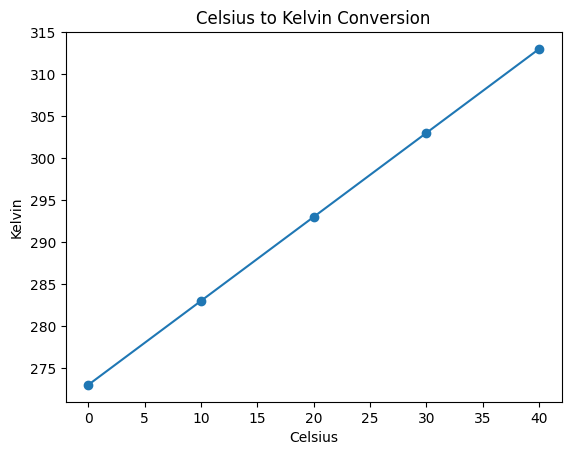

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

celsius = [0, 10, 20, 30, 40]

to_kelvin = lambda c: c + 273

kelvin = list(map(to_kelvin, celsius))

data = pd.DataFrame({
    "Celsius": celsius,
    "Kelvin": kelvin
})

print(data)

plt.plot(data["Celsius"], data["Kelvin"], marker='o')
plt.xlabel("Celsius")
plt.ylabel("Kelvin")
plt.title("Celsius to Kelvin Conversion")
plt.show()